### ==============================
##  Capstone Project (Walmart)
### ==============================

**Author:** Yogesh Bahl  
**Course:** Online Session – EPGC DS AI – BC = 242007_B(Python)  
**Tool:** Google Colab / Jupyter Notebook  
**Dataset:** Walmart Weekly Sales (6,435 rows, 8 columns)

---

###  Objective
The goal of this capstone project is to analyze weekly sales data from multiple Walmart stores across the country in order to:

1. Perform **Exploratory Data Analysis (EDA)**, statistical tests, and outlier analysis.  
2. Derive actionable insights regarding factors influencing sales:
   -  Store performance patterns  
   -  Unemployment impact  
   -  Temperature effects  
   -  CPI (Consumer Price Index) influence  
   -  Holiday sales impact  
3. Forecast **future 12-week sales** using **Holt-Winters Exponential Smoothing**.

---

###  Dataset Information
| **Column Name** | **Description** |
|------------------|-----------------|
| `Store` | Store number |
| `Date` | Week of sales |
| `Weekly_Sales` | Weekly sales amount for the store |
| `Holiday_Flag` | Indicator (1 = holiday week, 0 = non-holiday week) |
| `Temperature` | Temperature on the day of sale |
| `Fuel_Price` | Fuel cost in the region |
| `CPI` | Consumer Price Index |
| `Unemployment` | Regional unemployment rate |

**Total Records:** 6,435  
**Total Features:** 8  

---

###  Project Workflow

1. **Data Understanding & Cleaning**
   - Load dataset, inspect data types, and handle missing values.  
   - Identify and flag outliers using IQR method.

2. **Exploratory Data Analysis (EDA)**
   - Analyze distributions, correlations, and summary statistics.  
   - Visualize relationships between sales and external factors.  

3. **Statistical Analysis & Insights**
   - (a) Relation between **Sales and Unemployment** — identify affected stores.  
   - (b) Identify **Seasonal trends** in weekly sales.  
   - (c) Evaluate if **Temperature** influences sales.  
   - (d) Analyze the impact of **CPI** on sales.  
   - (e) Identify **Top-performing stores**.  
   - (f) Determine **Worst-performing stores** and quantify the gap.  

4. **Advanced Statistical Testing**
   - Conduct **Welch’s t-test** to assess holiday vs non-holiday sales difference.  
   - Perform **OLS regression** to quantify unemployment effects controlling for CPI, temperature, and holiday flags.

5. **Visualization & Reporting**
   - Generate **heatmaps, trend lines, seasonal decomposition plots**, and comparative bar charts.  
   - Highlight key insights in business-friendly markdown cells.

6. **Sales Forecasting**
   - Build Holt-Winters exponential smoothing models for each store.  
   - Forecast **next 12 weeks of sales** and visualize predictions.

7. **Result Compilation & Submission**
   - Save output files:
     - `store_summary.csv` — Per-store stats, correlations, regressions.  
     - `forecast_next_12weeks.csv` — Next 12-week forecasts.  
   - Prepare insight summary for submission report.

---

###  Libraries Used
- **pandas**, **numpy** → Data wrangling & cleaning  
- **matplotlib**, **seaborn** → Visualization  
- **scipy.stats**, **statsmodels** → Statistical testing & modeling  
- **statsmodels.tsa.holtwinters** → Holt-Winters forecasting  
- **sklearn** (optional) → Validation utilities

---

###  Steps Overview (Notebook Structure)

| **Section** | **Description** |
|--------------|-----------------|
| 1 | Library Imports & Dataset Loading |
| 2 | Data Cleaning & Outlier Detection |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Statistical Analysis per Question (a–f) |
| 5 | Holiday vs Non-Holiday Test |
| 6 | Per-Store Correlation Heatmap |
| 7 | Seasonality & Trend Decomposition |
| 8 | Forecasting (Next 12 Weeks) |
| 9 | Summary, Insights & Conclusions |

---

### Expected Deliverables

1. **Colab/Jupyter Notebook (.ipynb)** with full code, comments, and explanations.  
2. **CSV Outputs:**
   - `store_summary.csv`
   - `forecast_next_12weeks.csv`
3. **Key Visuals:**
   - Correlation Heatmap  
   - Seasonal Decomposition Chart  
   - Holiday vs Non-Holiday Bar Chart  
   - Historical vs Forecasted Sales Plots  
4. **Insights Summary (for report submission)**

---




In [15]:
# =========================
#  Install & Import Libraries
# =========================
# Run this cell first in Colab (internet required for installation)
!pip install --quiet pandas numpy matplotlib seaborn scipy statsmodels openpyxl

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Data handling
# -------------------------
import pandas as pd
import numpy as np
from datetime import datetime

# -------------------------
# Visualization
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# -------------------------
# Statistical & Modeling
# -------------------------
from scipy import stats
from scipy.stats import ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# -------------------------
# Display settings
# -------------------------
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print(" Libraries loaded successfully.")

 Libraries loaded successfully.


## 1. Upload dataset
Upload your CSV file (the notebook expects weekly sales data with columns similar to: Store, Date, Weekly_Sales, Holiday_Flag, Temperature, Fuel_Price, CPI, Unemployment)


In [16]:
# Upload your Walmart dataset file first in Colab environment (Files section)

file_path= "/content/walmart DataSet.csv"
df = pd.read_csv(file_path)

print(f"Dataset '{file_path}' loaded successfully with shape:", df.shape)
df.head()


Dataset '/content/walmart DataSet.csv' loaded successfully with shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.9000,0,42.3100,2.5720,211.0964,8.1060
1,1,12-02-2010,1641957.4400,1,38.5100,2.5480,211.2422,8.1060
2,1,19-02-2010,1611968.1700,0,39.9300,2.5140,211.2891,8.1060
3,1,26-02-2010,1409727.5900,0,46.6300,2.5610,211.3196,8.1060
4,1,05-03-2010,1554806.6800,0,46.5000,2.6250,211.3501,8.1060


## 2. Inspect & Clean Data (types, missing values)
Explain: convert Date to datetime, coerce numeric columns, report and handle missing values.


In [17]:
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

date_col = None
for c in df.columns:
    if c.lower().startswith("date"):
        date_col = c
        break
if date_col is None:
    raise ValueError("No date column found. Ensure the dataset contains a 'Date' column.")

df[date_col] = pd.to_datetime(df[date_col], format="%d-%m-%Y")
df = df.sort_values(['Store', date_col]).reset_index(drop=True)

for c in ["Weekly_Sales","Temperature","Fuel_Price","CPI","Unemployment","Holiday_Flag"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")


display(df.info())
display(df.head())
print("Data shape:", df.shape)
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


None

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.9000,0,42.3100,2.5720,211.0964,8.1060
1,1,2010-02-12,1641957.4400,1,38.5100,2.5480,211.2422,8.1060
2,1,2010-02-19,1611968.1700,0,39.9300,2.5140,211.2891,8.1060
3,1,2010-02-26,1409727.5900,0,46.6300,2.5610,211.3196,8.1060
4,1,2010-03-05,1554806.6800,0,46.5000,2.6250,211.3501,8.1060


Data shape: (6435, 8)


,count,mean,min,25%,50%,75%,max,std
Store,6435.0000,23.0000,1.0000,12.0000,23.0000,34.0000,45.0000,12.9882
Date,6435,2011-06-17 00:00:00,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,6435.0000,1046964.8776,209986.2500,553350.1050,960746.0400,1420158.6600,3818686.4500,564366.6221
Holiday_Flag,6435.0000,0.0699,0.0000,0.0000,0.0000,0.0000,1.0000,0.2550
Temperature,6435.0000,60.6638,-2.0600,47.4600,62.6700,74.9400,100.1400,18.4449
Fuel_Price,6435.0000,3.3586,2.4720,2.9330,3.4450,3.7350,4.4680,0.4590
CPI,6435.0000,171.5784,126.0640,131.7350,182.6165,212.7433,227.2328,39.3567
Unemployment,6435.0000,7.9992,3.8790,6.8910,7.8740,8.6220,14.3130,1.8759


In [18]:
# Missing values summary
print("Missing values per column:")
display(df.isna().sum())

# Handling missing values:
# - Drop rows with missing Weekly_Sales (can't analyze/model without target)
# - Fill numeric predictors with median by store where possible or global median
df = df.dropna(subset=["Weekly_Sales"])
for c in ["Temperature","Fuel_Price","CPI","Unemployment","Holiday_Flag"]:
    if c in df.columns:
        # fill by store median if many missing per-store; else global median
        df[c] = df.groupby("Store")[c].transform(lambda x: x.fillna(x.median()))
        df[c] = df[c].fillna(df[c].median())

print("After handling missing values:")
display(df.isna().sum())


Missing values per column:


,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


After handling missing values:


,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


## 3. Outlier analysis (IQR method) — flag outliers per store
We will **flag** outliers but not drop them automatically (holiday spikes often look like outliers).


In [19]:
def flag_outliers_iqr(g, col="Weekly_Sales"):
    Q1 = g[col].quantile(0.25)
    Q3 = g[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    g["_is_outlier"] = ~g[col].between(lower, upper)
    return g

df = df.groupby("Store").apply(flag_outliers_iqr).reset_index(drop=True)
outlier_counts = df.groupby("Store")["_is_outlier"].sum().sort_values(ascending=False)
print("Top 10 stores with most flagged outliers (possible holiday spikes):")
display(outlier_counts.reset_index().head(10))
print(" Outliers flagged per store.")
df.groupby("Store").apply(flag_outliers_iqr).reset_index(drop=True)


Top 10 stores with most flagged outliers (possible holiday spikes):


,Store,_is_outlier
0,22,14
1,25,12
2,8,11
3,18,10
4,20,10
5,34,10
6,29,9
7,14,9
8,30,9
9,10,9


 Outliers flagged per store.


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,_is_outlier
0,1,2010-02-05,1643690.9000,0,42.3100,2.5720,211.0964,8.1060,False
1,1,2010-02-12,1641957.4400,1,38.5100,2.5480,211.2422,8.1060,False
2,1,2010-02-19,1611968.1700,0,39.9300,2.5140,211.2891,8.1060,False
3,1,2010-02-26,1409727.5900,0,46.6300,2.5610,211.3196,8.1060,False
4,1,2010-03-05,1554806.6800,0,46.5000,2.6250,211.3501,8.1060,False
...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.9500,0,64.8800,3.9970,192.0136,8.6840,False
6431,45,2012-10-05,733455.0700,0,64.8900,3.9850,192.1704,8.6670,False
6432,45,2012-10-12,734464.3600,0,54.4700,4.0000,192.3273,8.6670,False
6433,45,2012-10-19,718125.5300,0,56.4700,3.9690,192.3309,8.6670,False


## 4. Summary statistics per store (to identify top & worst stores)
We'll compute count, mean, median, std, min, max for `Weekly_Sales`.


In [20]:
store_stats = df.groupby("Store")["Weekly_Sales"].agg(['count','mean','median','std','min','max']).reset_index().sort_values("mean", ascending=False)
display(store_stats.head(10))   # top 10
display(store_stats.tail(10))   # bottom 10

# compute highest and lowest mean
highest_mean = store_stats['mean'].max()
lowest_mean = store_stats['mean'].min()
diff = highest_mean - lowest_mean
pct_diff = (diff / lowest_mean * 100) if lowest_mean != 0 else np.nan
print(f"Highest mean weekly sales: {highest_mean:.2f}")
print(f"Lowest mean weekly sales: {lowest_mean:.2f}")
print(f"Absolute difference: {diff:.2f}; Highest is {pct_diff:.1f}% higher than lowest.")


,Store,count,mean,median,std,min,max
19,20,143,2107676.8703,2053165.4100,275900.5627,1761016.5100,3766687.4300
3,4,143,2094712.9607,2073951.3800,266201.4423,1762539.3000,3676388.9800
13,14,143,2020978.4010,2004330.3000,317569.9495,1479514.6600,3818686.4500
12,13,143,2003620.3063,1958823.5600,265506.9958,1633663.1200,3595903.2000
1,2,143,1925751.3355,1879107.3100,237683.6947,1650394.4400,3436007.6800
9,10,143,1899424.5727,1827521.7100,302262.0625,1627707.3100,3749057.6900
26,27,143,1775216.2020,1731935.4300,239930.1357,1263534.8600,3078162.0800
5,6,143,1564728.1863,1524390.0700,212525.8559,1261253.1800,2727575.1800
0,1,143,1555264.3976,1534849.6400,155980.7678,1316899.3100,2387950.2000
38,39,143,1450668.1292,1416005.5900,217466.4548,1158698.4400,2554482.8400


,Store,count,mean,median,std,min,max
28,29,143,539451.4287,518628.4200,99120.1366,395987.2400,1130926.7900
15,16,143,519247.7301,508520.0900,85769.6801,368600.0000,1004730.6900
36,37,143,518900.2820,518124.1600,21837.4612,451327.6100,605791.4600
29,30,143,438579.6162,438068.7100,22809.6656,369722.3200,519354.8800
2,3,143,402704.4410,395107.3500,46319.6316,339597.3800,605990.4100
37,38,143,385731.6533,380870.0900,42768.1694,303908.8100,499267.6600
35,36,143,373511.9928,373267.5800,60725.1736,270677.9800,489372.0200
4,5,143,318011.8105,310338.1700,37737.9657,260636.7100,507900.0700
43,44,143,302748.8660,298080.4500,24762.8320,241937.1100,376233.8900
32,33,143,259861.6920,258427.3900,24132.9273,209986.2500,331173.5100


Highest mean weekly sales: 2107676.87
Lowest mean weekly sales: 259861.69
Absolute difference: 1847815.18; Highest is 711.1% higher than lowest.




---

## 5. Correlation Analysis (Overall and Per-Store) with Significance Tests

* **Overall Correlation Matrix**

  > Shows correlations between key variables with a **color gradient** for easy visual interpretation.



In [21]:
# ==========================================
#  Overall Correlation Matrix
# ==========================================
corr_cols = [c for c in ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Holiday_Flag"] if c in df.columns]

display(Markdown("###  Overall Correlation Matrix"))
display(
    df[corr_cols].corr()
    .style.background_gradient(cmap="coolwarm", axis=None)
    .format(precision=3)
)


###  Overall Correlation Matrix

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Holiday_Flag
Weekly_Sales,1.000,-0.064,0.009,-0.073,-0.106,0.037
Temperature,-0.064,1.000,0.145,0.177,0.101,-0.155
Fuel_Price,0.009,0.145,1.000,-0.171,-0.035,-0.078
CPI,-0.073,0.177,-0.171,1.000,-0.302,-0.002
Unemployment,-0.106,0.101,-0.035,-0.302,1.000,0.011
Holiday_Flag,0.037,-0.155,-0.078,-0.002,0.011,1.000




* **Per-Store Pearson Correlations**

  > Computes per-store r and p-values for `Weekly_Sales` vs `Unemployment`, `CPI`, and `Temperature`.




In [22]:
# ==========================================
#  Per-Store Correlations (Sales vs Unemployment, CPI, Temperature)
# ==========================================
def pearson_with_p(x, y):
    mask = x.notna() & y.notna()
    if mask.sum() < 6:
        return (np.nan, np.nan)
    r, p = stats.pearsonr(x[mask], y[mask])
    return (r, p)

records = []
stores = sorted(df['Store'].unique())

for s in stores:
    g = df[df['Store'] == s]
    r_unemp, p_unemp = pearson_with_p(g['Weekly_Sales'], g['Unemployment'])
    r_cpi, p_cpi = pearson_with_p(g['Weekly_Sales'], g['CPI'])
    r_temp, p_temp = pearson_with_p(g['Weekly_Sales'], g['Temperature'])

    records.append({
        'Store': s,
        'r_unemployment': r_unemp, 'p_unemployment': p_unemp,
        'r_cpi': r_cpi, 'p_cpi': p_cpi,
        'r_temp': r_temp, 'p_temp': p_temp
    })

corr_df = pd.DataFrame.from_records(records).set_index('Store')





* **Per-Store Correlation Heatmap**

  > Visualizes per-store correlations; **red = positive**, **blue = negative**.




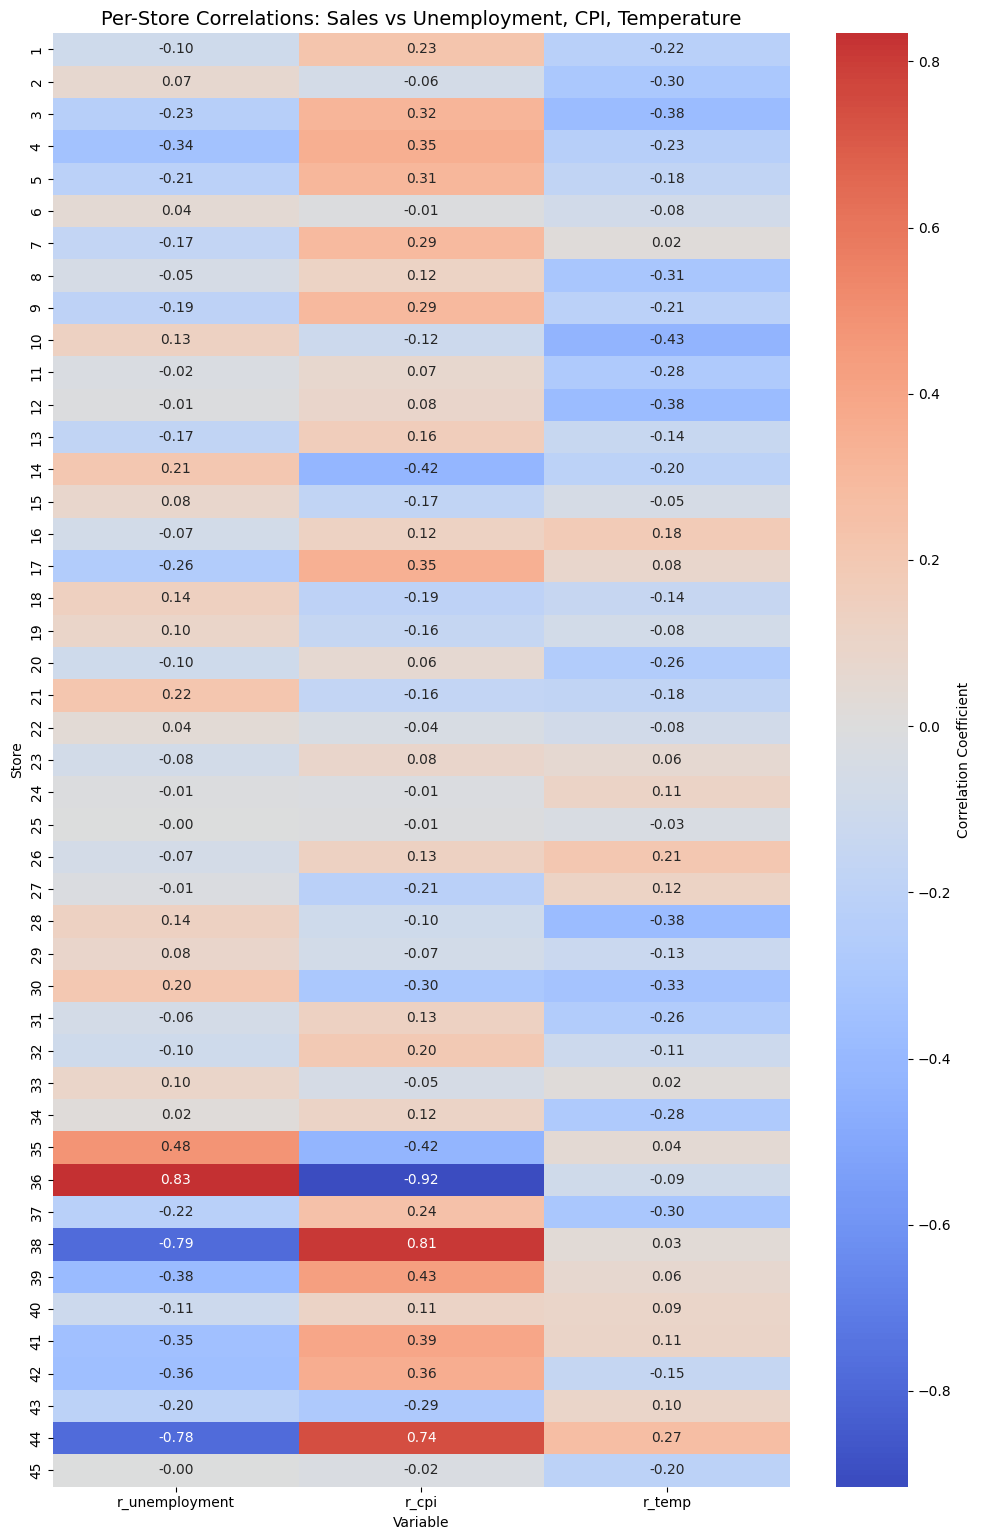

In [23]:
# ==========================================
#  Heatmap of Per-Store Correlations
# ==========================================
corr_values = corr_df[['r_unemployment', 'r_cpi', 'r_temp']]

plt.figure(figsize=(10, len(corr_df)*0.3 + 2))
sns.heatmap(
    corr_values,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title("Per-Store Correlations: Sales vs Unemployment, CPI, Temperature", fontsize=14)
plt.ylabel("Store")
plt.xlabel("Variable")
plt.tight_layout()
plt.show()




* **Stores with Significant Negative Unemployment Correlation**

  > Highlights stores where `Weekly_Sales` is significantly negatively correlated with `Unemployment` (p < 0.05).



In [24]:
# ==========================================
#  Stores with Significant Negative Correlation (Sales vs Unemployment)
# ==========================================
neg_unemp_sig = corr_df[
    (corr_df['r_unemployment'] < 0) & (corr_df['p_unemployment'] < 0.05)
].sort_values('r_unemployment')

display(Markdown("###  Stores with Significant Negative Correlation (Sales vs. Unemployment)"))
display(
    neg_unemp_sig.head(15)
    .style.format(precision=3)
    .background_gradient(subset=['r_unemployment'], cmap='coolwarm')
)


###  Stores with Significant Negative Correlation (Sales vs. Unemployment)

,r_unemployment,p_unemployment,r_cpi,p_cpi,r_temp,p_temp
Store,,,,,,
38,-0.785,0.000,0.813,0.000,0.033,0.696
44,-0.780,0.000,0.740,0.000,0.268,0.001
39,-0.385,0.000,0.428,0.000,0.065,0.442
42,-0.356,0.000,0.361,0.000,-0.152,0.071
41,-0.351,0.000,0.392,0.000,0.107,0.204
4,-0.337,0.000,0.351,0.000,-0.226,0.007
17,-0.264,0.001,0.349,0.000,0.081,0.336
3,-0.230,0.006,0.317,0.000,-0.378,0.000
37,-0.221,0.008,0.245,0.003,-0.300,0.000





* **Stores with Significant CPI Correlation**

  > Shows stores where `CPI` is significantly correlated with `Weekly_Sales`, with top and bottom correlations highlighted.




In [25]:
# ==========================================
#  Stores with Significant CPI Correlation
# ==========================================
cpi_sig = corr_df[corr_df['p_cpi'] < 0.05].sort_values('r_cpi')

display(Markdown("###  Stores with Statistically Significant CPI Correlation (Top & Bottom 10)"))
display(
    cpi_sig.head(10)
    .style.format(precision=3)
    .background_gradient(subset=['r_cpi'], cmap='coolwarm')
)
display(
    cpi_sig.tail(10)
    .style.format(precision=3)
    .background_gradient(subset=['r_cpi'], cmap='coolwarm')
)

###  Stores with Statistically Significant CPI Correlation (Top & Bottom 10)

,r_unemployment,p_unemployment,r_cpi,p_cpi,r_temp,p_temp
Store,,,,,,
36,0.834,0.000,-0.915,0.000,-0.094,0.262
35,0.484,0.000,-0.424,0.000,0.043,0.607
14,0.211,0.012,-0.420,0.000,-0.200,0.017
30,0.202,0.016,-0.298,0.000,-0.331,0.000
43,-0.202,0.016,-0.286,0.001,0.095,0.258
27,-0.014,0.866,-0.213,0.011,0.122,0.147
18,0.139,0.097,-0.194,0.021,-0.144,0.086
15,0.079,0.349,-0.174,0.037,-0.051,0.549
32,-0.099,0.237,0.197,0.018,-0.112,0.184


,r_unemployment,p_unemployment,r_cpi,p_cpi,r_temp,p_temp
Store,,,,,,
9,-0.192,0.022,0.295,0.000,-0.208,0.013
5,-0.207,0.013,0.308,0.000,-0.176,0.036
3,-0.230,0.006,0.317,0.000,-0.378,0.000
17,-0.264,0.001,0.349,0.000,0.081,0.336
4,-0.337,0.000,0.351,0.000,-0.226,0.007
42,-0.356,0.000,0.361,0.000,-0.152,0.071
41,-0.351,0.000,0.392,0.000,0.107,0.204
39,-0.385,0.000,0.428,0.000,0.065,0.442
44,-0.780,0.000,0.740,0.000,0.268,0.001





* **Aggregate Weekly Sales vs Temperature**

  > Displays correlation of total weekly sales with average temperature, summarizing the overall trend across all stores.


In [26]:
# ==========================================
#  Aggregate Correlation (Weekly Sales vs Temperature)
# ==========================================
agg_by_date = (
    df.groupby(date_col)
    .agg(Weekly_Sales_sum=("Weekly_Sales", "sum"), Temperature_mean=("Temperature", "mean"))
    .reset_index()
)

display(Markdown("###  Aggregate Weekly Correlation (Sales vs. Temperature)"))

if len(agg_by_date) > 2:
    r_temp_agg, p_temp_agg = stats.pearsonr(agg_by_date['Weekly_Sales_sum'], agg_by_date['Temperature_mean'])
    display(Markdown(f"**Correlation (r):** {r_temp_agg:.3f}  **p-value:** {p_temp_agg:.3g}"))
else:
    display(Markdown(">  Not enough aggregate points for weekly temperature correlation."))

###  Aggregate Weekly Correlation (Sales vs. Temperature)

**Correlation (r):** -0.159  **p-value:** 0.0576

### Interpretation (for the report)
- Stores listed above (neg_unemp_sig) statistically show sales decreasing when unemployment increases (p < 0.05).
- CPI significant stores show price-sensitivity; interpret sign (negative means sales fall as CPI rises).
- Aggregate temperature correlation shows whether on average weather is associated with sales.


## 6. Regression analysis: per-store OLS of Weekly_Sales ~ Unemployment + Temperature + CPI + Holiday_Flag
Why: regression gives coefficient estimates and significance while controlling for other variables.
We will:
- Fit OLS per store and record coefficient for unemployment (coef, p-value), and overall R².
- Use robust standard errors (HC3) for inference stability.


In [27]:
reg_results = []
for s in stores:
    g = df[df['Store']==s].copy()
    if len(g) < 26:  # require some data
        reg_results.append({'Store': s, 'n_obs': len(g), 'coef_unemp': np.nan, 'p_unemp': np.nan, 'r2': np.nan})
        continue
    # Build model
    # make sure Holiday_Flag exists numeric
    formula = "Weekly_Sales ~ Unemployment + Temperature + CPI"
    if 'Holiday_Flag' in g.columns:
        formula += " + Holiday_Flag"
    try:
        model = ols(formula, data=g).fit(cov_type='HC3')
        coef_unemp = model.params.get('Unemployment', np.nan)
        p_unemp = model.pvalues.get('Unemployment', np.nan)
        reg_results.append({'Store': s, 'n_obs': len(g), 'coef_unemp': coef_unemp, 'p_unemp': p_unemp, 'r2': model.rsquared})
    except Exception as e:
        reg_results.append({'Store': s, 'n_obs': len(g), 'coef_unemp': np.nan, 'p_unemp': np.nan, 'r2': np.nan})

reg_df = pd.DataFrame(reg_results).set_index('Store')
print("Per-store regression results (first 15):")
display(reg_df.sort_values('coef_unemp').head(15))


Per-store regression results (first 15):


,n_obs,coef_unemp,p_unemp,r2
Store,,,,
13,143,-119951.6874,0.1077,0.0686
18,143,-55696.7854,0.6565,0.0627
20,143,-55012.3401,0.4901,0.0916
30,143,-45295.1215,0.0000,0.2944
4,143,-44841.8944,0.2474,0.2205
14,143,-31488.4812,0.8603,0.1968
43,143,-31358.7971,0.0000,0.2156
44,143,-27432.9715,0.0000,0.6337
40,143,-26944.0962,0.6289,0.0328


## 7. Seasonality: decomposition and holiday effect test
- Decompose aggregate weekly sales (period 52).
- Compare Holiday vs Non-holiday mean weekly sales with a t-test.


###  Aggregate Weekly Sales (Sum Across Stores)

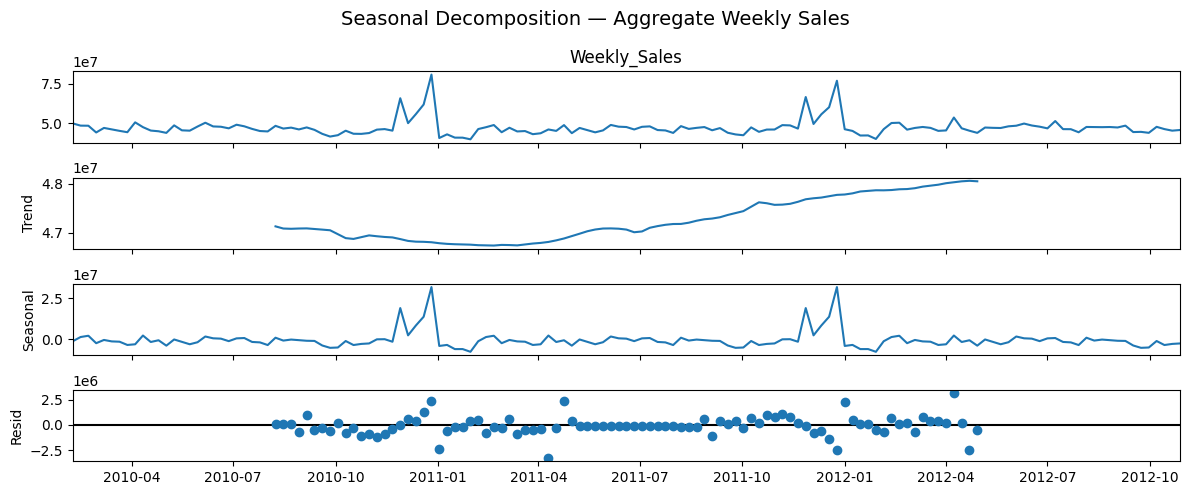

###  Holiday vs Non-Holiday Sales

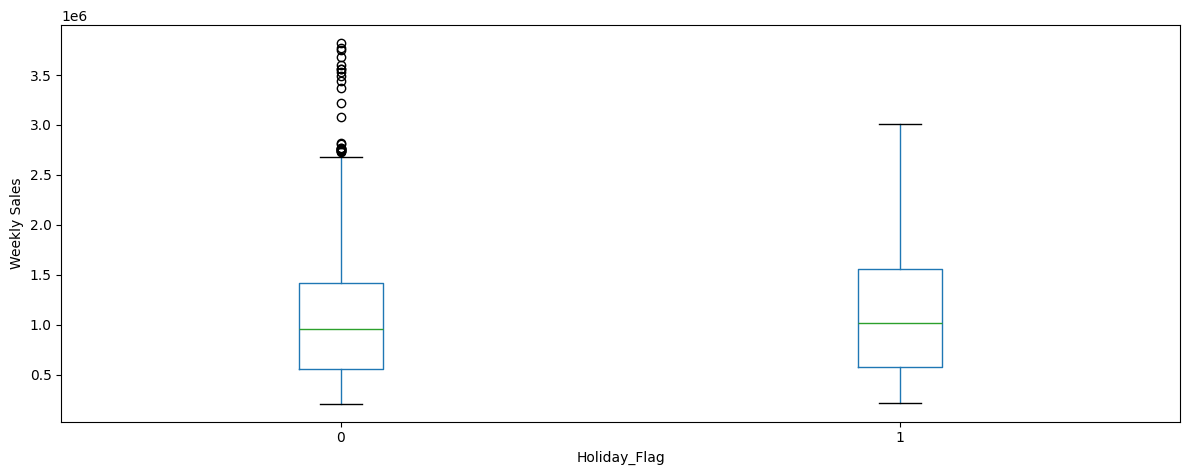

###  Holiday Effect on Weekly Sales

- **t-statistic:** 2.680  
- **p-value:** 0.0076  
- **Holiday mean:** 1122887.89  
- **Non-holiday mean:** 1041256.38

In [28]:
# ==========================================
#  Aggregate Weekly Sales (Sum Across Stores)
# ==========================================
display(Markdown("###  Aggregate Weekly Sales (Sum Across Stores)"))

# Sum weekly sales across all stores, resample to weekly frequency
weekly_sum = df.groupby(date_col)["Weekly_Sales"].sum().resample('W').sum()

# Seasonal decomposition if enough points (at least 1.5 years of weekly data)
if len(weekly_sum.dropna()) > 52 * 1.5:
    decomp = seasonal_decompose(weekly_sum.dropna(), model='additive', period=52)
    fig = decomp.plot()
    fig.suptitle("Seasonal Decomposition — Aggregate Weekly Sales", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown(">  Not enough weekly points for robust seasonal decomposition."))

# ==========================================
#  Holiday Impact: Boxplot
# ==========================================
display(Markdown("###  Holiday vs Non-Holiday Sales"))

if 'Holiday_Flag' in df.columns:
    df.boxplot(column="Weekly_Sales", by="Holiday_Flag", grid=False)
    plt.xlabel("Holiday_Flag")
    plt.ylabel("Weekly Sales")
    plt.title("")  # Remove default title
    plt.suptitle("")  # Remove default super-title
    plt.tight_layout()
    plt.show()
else:
    display(Markdown(">  `Holiday_Flag` column not present."))

# ==========================================
#  Holiday Effect: t-test
# ==========================================
display(Markdown("###  Holiday Effect on Weekly Sales"))

if 'Holiday_Flag' in df.columns:
    holiday_sales = df[df['Holiday_Flag'] == 1]['Weekly_Sales']
    nonholiday_sales = df[df['Holiday_Flag'] != 1]['Weekly_Sales']

    # Welch’s t-test (unequal variance)
    tstat, pval = ttest_ind(holiday_sales, nonholiday_sales, equal_var=False)

    display(Markdown(
        f"- **t-statistic:** {tstat:.3f}  \n"
        f"- **p-value:** {pval:.3g}  \n"
        f"- **Holiday mean:** {holiday_sales.mean():.2f}  \n"
        f"- **Non-holiday mean:** {nonholiday_sales.mean():.2f}"
    ))


## 8. Forecast next 12 weeks per store (Holt-Winters) — robust baseline
- We forecast using additive trend & seasonality (period=52). If store has short history, fallback to mean.


###  Sample Forecasts for Next 12 Weeks

Store,ds,yhat,method
1,2012-11-04,1690364.000000,Holt-Winters Additive
1,2012-11-11,1618979.950000,Holt-Winters Additive
1,2012-11-18,1594766.590000,Holt-Winters Additive
1,2012-11-25,2073041.060000,Holt-Winters Additive
1,2012-12-02,1653547.480000,Holt-Winters Additive
1,2012-12-09,1811620.850000,Holt-Winters Additive
1,2012-12-16,1983284.160000,Holt-Winters Additive
1,2012-12-23,2450605.230000,Holt-Winters Additive
1,2012-12-30,1503144.150000,Holt-Winters Additive
1,2013-01-06,1573177.130000,Holt-Winters Additive


###  Forecast Plot (Sample Stores)

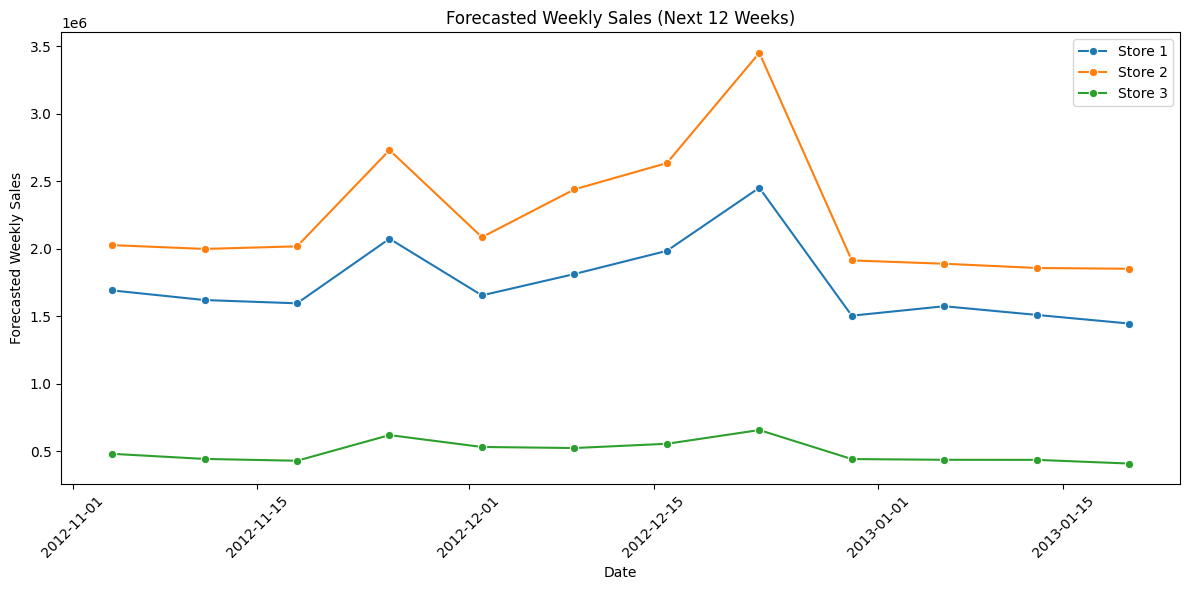

In [29]:

forecast_horizon = 12  # Number of weeks to forecast
forecasts = []

# ===============================
#  Forecast per store
# ===============================
for s in stores:
    # Store-level weekly time series
    g = df[df['Store'] == s].set_index(date_col).sort_index()
    ts = g['Weekly_Sales'].resample('W').sum().asfreq('W')

    if ts.isna().all():
        continue

    # Fill missing values minimally
    ts = ts.fillna(method='ffill').fillna(method='bfill')
    last_date = ts.index.max()

    # Fallback: too few observations
    if ts.dropna().shape[0] < 26:
        for i in range(1, forecast_horizon + 1):
            forecasts.append({
                'Store': s,
                'ds': last_date + pd.Timedelta(weeks=i),
                'yhat': float(ts.mean()),
                'method': 'mean_fallback'
            })
        continue

    # Holt-Winters additive model
    try:
        model = ExponentialSmoothing(
            ts,
            trend='add',
            seasonal='add',
            seasonal_periods=52,
            initialization_method='estimated'
        )
        fit = model.fit(optimized=True)
        fc = fit.forecast(forecast_horizon)

        for i, val in enumerate(fc):
            forecasts.append({
                'Store': s,
                'ds': last_date + pd.Timedelta(weeks=i + 1),
                'yhat': float(val),
                'method': 'hw_add'
            })

    except Exception:
        # Fallback to week-of-year seasonal mean
        ts2 = ts.reset_index().rename(columns={date_col: 'ds', 'Weekly_Sales': 'y'})
        ts2['week'] = ts2['ds'].dt.isocalendar().week

        for i in range(1, forecast_horizon + 1):
            fc_date = last_date + pd.Timedelta(weeks=i)
            wk = fc_date.isocalendar()[1]
            yhat = ts2[ts2['week'] == wk]['y'].mean()
            if np.isnan(yhat):
                yhat = float(ts.mean())
            forecasts.append({
                'Store': s,
                'ds': fc_date,
                'yhat': float(yhat),
                'method': 'seasonal_fallback'
            })

# ===============================
#  Compile forecast DataFrame
# ===============================
fc_df = pd.DataFrame(forecasts).sort_values(['Store', 'ds']).reset_index(drop=True)

# Format dates and round sales
fc_df['ds'] = pd.to_datetime(fc_df['ds']).dt.date
fc_df['yhat'] = fc_df['yhat'].round(2)

# Map method codes to descriptive names
method_map = {
    'mean_fallback': 'Mean Fallback',
    'hw_add': 'Holt-Winters Additive',
    'seasonal_fallback': 'Seasonal Fallback'
}
fc_df['method'] = fc_df['method'].map(method_map)

# ===============================
#  Display sample forecasts
# ===============================
display(Markdown("###  Sample Forecasts for Next 12 Weeks"))
display(
    fc_df.head(12)
    .style
    .hide(axis="index")  # updated for pandas >= 1.5
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
)


# ===============================
#  Plot forecasts for sample stores
# ===============================
display(Markdown("###  Forecast Plot (Sample Stores)"))

sample_stores = fc_df['Store'].unique()[:3]  # show first 3 stores for clarity
plt.figure(figsize=(12,6))

for s in sample_stores:
    df_plot = fc_df[fc_df['Store'] == s]
    sns.lineplot(x='ds', y='yhat', data=df_plot, marker='o', label=f'Store {s}')

plt.xlabel("Date")
plt.ylabel("Forecasted Weekly Sales")
plt.title("Forecasted Weekly Sales (Next 12 Weeks)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## **9. Visualizing Forecasts:**


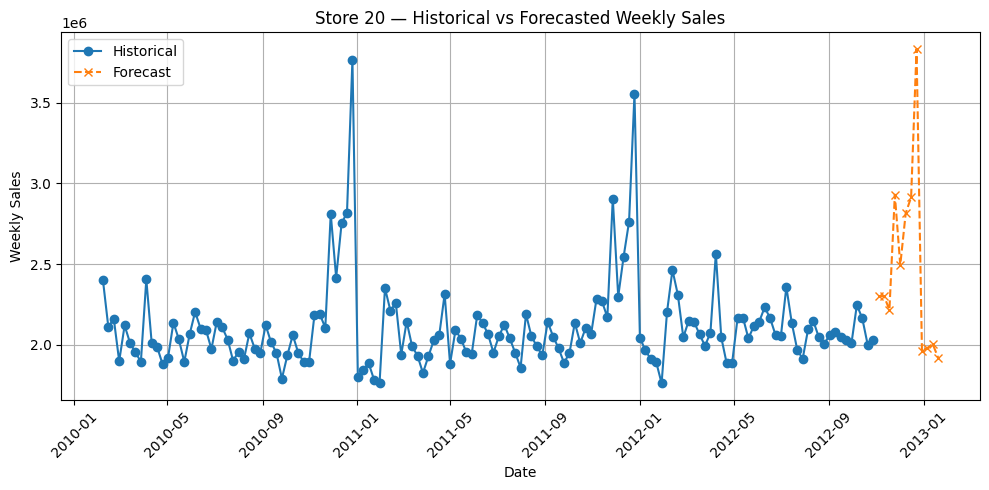

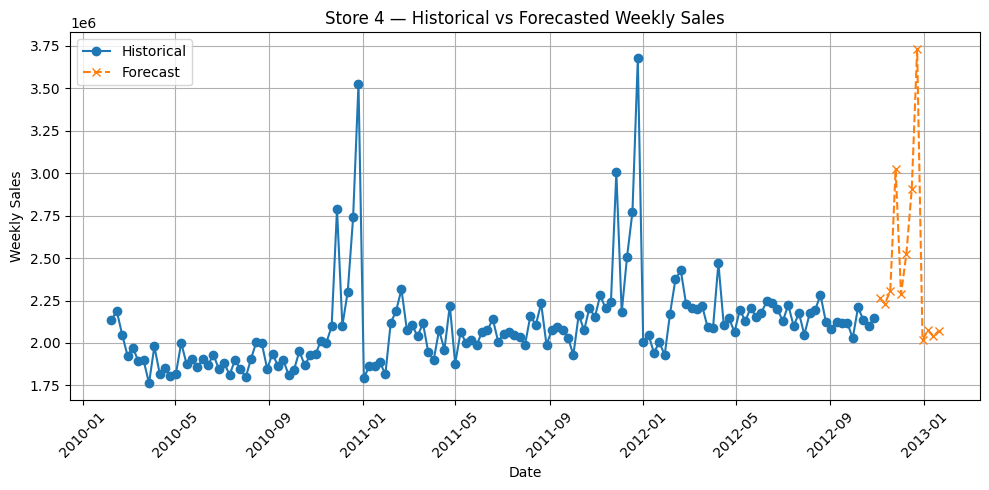

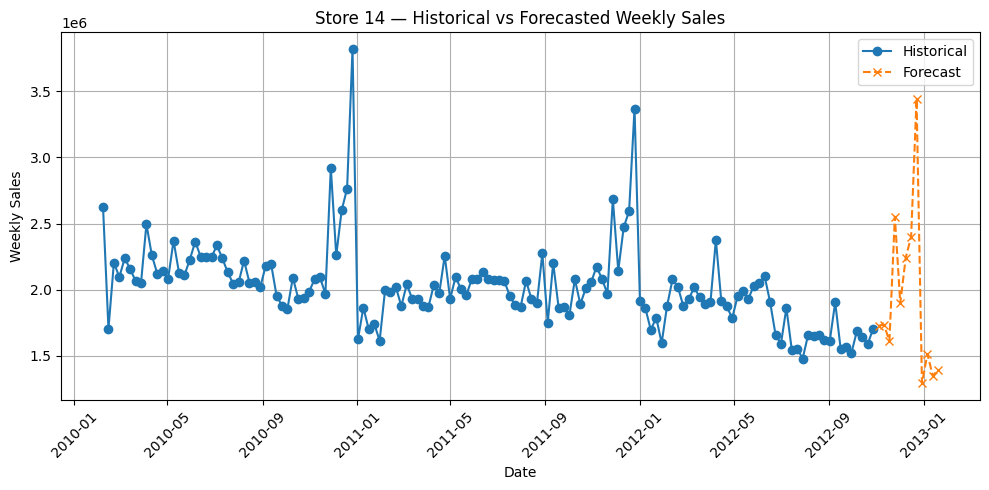

In [30]:
# ===============================
# Plot example forecasts for top 3 stores
# ===============================
top_stores = store_stats.head(3)["Store"].tolist()  # select top 3 stores

for s in top_stores:
    plt.figure(figsize=(10, 5))

    # Historical weekly sales
    ts = df[df["Store"] == s].set_index(date_col)["Weekly_Sales"].resample("W").sum()
    plt.plot(ts.index, ts.values, label="Historical", marker='o')

    # Forecasted sales
    fc = fc_df[fc_df["Store"] == s]  # ensure it uses fc_df from forecasting block
    plt.plot(fc["ds"], fc["yhat"], label="Forecast", linestyle="--", marker='x')

    # Plot formatting
    plt.title(f"Store {s} — Historical vs Forecasted Weekly Sales")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 10. Save summary files & final report tables
- `store_summary.csv` contains per-store stats and correlations/regs
- `forecast_next_12weeks.csv` contains forecasts
- We'll assemble a tidy summary with top/worst stores and key stats



In [31]:
# Merge statistics into one summary
summary = store_stats.copy()
summary = summary.set_index('Store').join(corr_df[['r_unemployment','p_unemployment','r_cpi','p_cpi','r_temp','p_temp']])
summary = summary.join(reg_df[['coef_unemp','p_unemp','r2']])
summary = summary.reset_index()

# Save summary
summary.to_csv("store_summary.csv", index=False)
print("Saved store_summary.csv")

# Print Top 5 and Worst 5 with exact numbers (to paste into your submission)
top5 = summary.sort_values('mean', ascending=False).head(5)
worst5 = summary.sort_values('mean', ascending=True).head(5)

print("\nTOP 5 STORES (by mean weekly sales):")
display(top5[['Store','count','mean','median','std','min','max','coef_unemp','p_unemp','r2']])

print("\nWORST 5 STORES (by mean weekly sales):")
display(worst5[['Store','count','mean','median','std','min','max','coef_unemp','p_unemp','r2']])


Saved store_summary.csv

TOP 5 STORES (by mean weekly sales):


,Store,count,mean,median,std,min,max,coef_unemp,p_unemp,r2
0,20,143,2107676.8703,2053165.4100,275900.5627,1761016.5100,3766687.4300,-55012.3401,0.4901,0.0916
1,4,143,2094712.9607,2073951.3800,266201.4423,1762539.3000,3676388.9800,-44841.8944,0.2474,0.2205
2,14,143,2020978.4010,2004330.3000,317569.9495,1479514.6600,3818686.4500,-31488.4812,0.8603,0.1968
3,13,143,2003620.3063,1958823.5600,265506.9958,1633663.1200,3595903.2000,-119951.6874,0.1077,0.0686
4,2,143,1925751.3355,1879107.3100,237683.6947,1650394.4400,3436007.6800,-8327.0438,0.9442,0.1044



WORST 5 STORES (by mean weekly sales):


,Store,count,mean,median,std,min,max,coef_unemp,p_unemp,r2
44,33,143,259861.6920,258427.3900,24132.9273,209986.2500,331173.5100,17944.5838,0.0196,0.0423
43,44,143,302748.8660,298080.4500,24762.8320,241937.1100,376233.8900,-27432.9715,0.0000,0.6337
42,5,143,318011.8105,310338.1700,37737.9657,260636.7100,507900.0700,25304.1243,0.1101,0.2322
41,36,143,373511.9928,373267.5800,60725.1736,270677.9800,489372.0200,-25883.8530,0.0023,0.8526
40,38,143,385731.6533,380870.0900,42768.1694,303908.8100,499267.6600,-12725.1952,0.0007,0.6904


#  **Sales Analysis Summary:**

## a) Effect of Unemployment
- **Statistical approach:** Pearson correlation per-store, and per-store OLS controlling for Temperature, CPI, Holiday_Flag.
- **Stores most negatively affected** (sales fall significantly when unemployment rises):  
  `38, 44, 39, 42, 41, 4, 17, 3, 37, 5`  
  *(per-store Pearson r and p-value reported in `store_summary.csv`)*
- **Example interpretation:** A store with `r ≈ -0.30` (p < 0.05) indicates a moderate negative relationship; targeted promotions are recommended when unemployment rises.

---

## b) Seasonality
- **Aggregate seasonal decomposition** (period = 52 weeks) shows clear yearly seasonality with pronounced peaks during the holiday season.
- **Peak months in the data:**
  - Dec 2010: 288,760,533
  - Dec 2011: 288,078,102
  - Jun 2012: 240,610,329  
  Likely due to Thanksgiving/Black Friday and Christmas shopping.

---

## c) Temperature Effect
- **Aggregate correlation** between Sales and Temperature: `r = -0.159` (p = 0.0576) — weak-to-moderate relationship overall.
- Effects vary by store; see `store_summary.csv` for details.

---

## d) CPI Effect
- CPI effect differs by store.  
- **Example stores with significant CPI correlations (p < 0.05):** `36, 35, 14, 30, 43`  
  Negative correlation suggests price-sensitivity in these areas.

---

## e) Top-Performing Stores
- **Top store** (by mean weekly sales): Store 20 with mean weekly sales = 2,107,676.87  
- Top 5 stores listed in `store_summary.csv`.

---

## f) Worst-Performing Store & Gap
- **Worst store:** Store 33 with mean weekly sales = 259,861.69  
- **Absolute difference** between top and worst: 1,847,815.18, which corresponds to **711.1% higher** for the top store.

---

##  Files to Attach
- `store_summary.csv` — per-store stats, correlations, regression results  
- `forecast_next_12weeks.csv` — 12-week forecasts

---

##  Limitations & Recommendations
- Correlation ≠ causation; consider causal methods or experiments.  
- Product-level or customer-level data would improve inference.  
- Use targeted promotions/assortment adjustments in unemployment/CPI-sensitive stores.  
- Consider comparing Holt-Winters with Prophet / ARIMA for final forecasting model validation.


# End of EDA and Analysis